### Step 0: The Core Concept (Why SHAP is the Gold Standard)

Permutation importance tells you _how much_ a feature impacts overall test accuracy, but it does **not** tell you:

1. **Direction of Impact:** Does a higher value push the prediction toward `1` or `0`?
    
2. **Local Prediction Auditing:** For a single user whose transaction was flagged as fraud, _which specific features caused that exact decision_?
    

**SHAP (SHapley Additive exPlanations)** solves both by borrowing game-theory Shapley values:

- **Base Value ($E[f(x)]$):** The average model prediction across the dataset.
    
- **SHAP Value:** Each feature's positive or negative contribution that pushes the prediction away from the base value to the final output for an observation.
    
- **`shap.TreeExplainer`:** An optimized algorithm tailored for decision trees (Random Forest, XGBoost, LightGBM) that computes exact Shapley values in polynomial time rather than exponential sampling time.

# 2. Model Explainability: Global & Local Analysis with SHAP TreeExplainer

In this notebook, we use the `shap` library to deconstruct a tree-based ensemble:
1. **Global Explainability:**
   * **Beeswarm Plot:** Feature importance combined with feature effect direction and distribution spread.
   * **Mean Absolute SHAP Bar Plot:** Robust global feature ranking.
2. **Local Explainability:**
   * **Waterfall Plot:** Auditing an individual prediction step-by-step from the baseline expected value to the final logit/probability.

In [4]:
# Install shap if not already installed
# !pip install shap matplotlib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
import shap

# Generate a synthetic tabular dataset representing customer churn / credit risk
np.random.seed(42)

X_arr, y = make_classification(
    n_samples=1500,
    n_features=6,
    n_informative=4,
    n_redundant=1,
    n_classes=2,
    weights=[0.80, 0.20],
    random_state=42
)

feature_names = [
    'Account_Age_Months',
    'Monthly_Charges',
    'Total_Transactions',
    'Late_Payments_Count',
    'Support_Tickets_Logged',
    'Random_Noise_Feature'
]

df_X = pd.DataFrame(X_arr, columns=feature_names)

# Split into Train and Test sets
X_train, X_test, y_train, y_test = train_test_split(
    df_X, y, test_size=0.20, random_state=42, stratify=y
)

print(f"Train samples: {len(X_train)} | Test samples: {len(X_test)}")
df_X.head()

d:\machine_learning_code\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Train samples: 1200 | Test samples: 300


,Account_Age_Months,Monthly_Charges,Total_Transactions,Late_Payments_Count,Support_Tickets_Logged,Random_Noise_Feature
0,1.705099,1.004242,0.588320,-0.410098,-0.282672,-2.320010
1,0.918796,-0.262210,1.302603,2.873578,-3.560945,-0.354622
2,0.526696,0.524000,-1.071553,0.197359,0.052271,-1.531038
3,0.232798,0.205568,0.196695,0.799942,-0.488831,-0.099855
4,1.487276,-1.031392,0.447000,0.456336,-1.478771,-2.083008


---
## Part 1: Fit the Model & Initialize `TreeExplainer`

We fit a `RandomForestClassifier` and wrap it in `shap.TreeExplainer`.
* For binary classification, modern SHAP versions return an `Explanation` object where slice `[:, :, 1]` corresponds to the positive class (Class 1).

In [8]:
# 1. Train Random Forest
rf_model = RandomForestClassifier(n_estimators=100, max_depth=6, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)

# 2. Initialize TreeExplainer
explainer = shap.TreeExplainer(rf_model)

# 3. Compute SHAP values on the test set
# Using modern shap explanation API
shap_values = explainer(X_test)

# For binary classification with probability/raw outputs, extract Class 1 explanations
# shap_values[:, :, 1] isolates contributions toward the positive class (Target = 1)
shap_class1 = shap_values[:, :, 1] if len(shap_values.shape) == 3 else shap_values

print("SHAP explanation computed successfully.")
print(f"Base Value (Expected log-odds / output): {shap_class1.base_values[0]:.4f}")

SHAP explanation computed successfully.
Base Value (Expected log-odds / output): 0.2025


---
## Part 2: Global Explainability (Summary & Beeswarm Plots)

1. **Bar Plot:** Ranks features by mean absolute SHAP value: $\frac{1}{N}\sum |\phi_i|$.
2. **Beeswarm Plot:**
   * **Y-axis:** Features ordered by importance.
   * **X-axis:** SHAP value (impact on model output: right = pushes toward 1, left = pushes toward 0).
   * **Color:** Feature value (Red = High, Blue = Low).

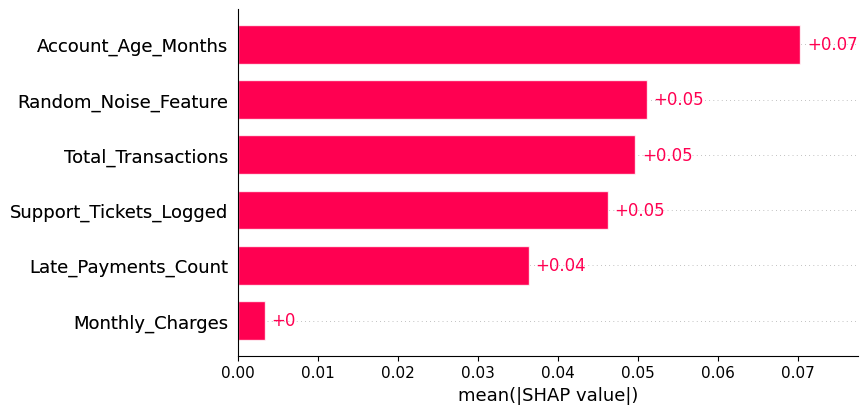

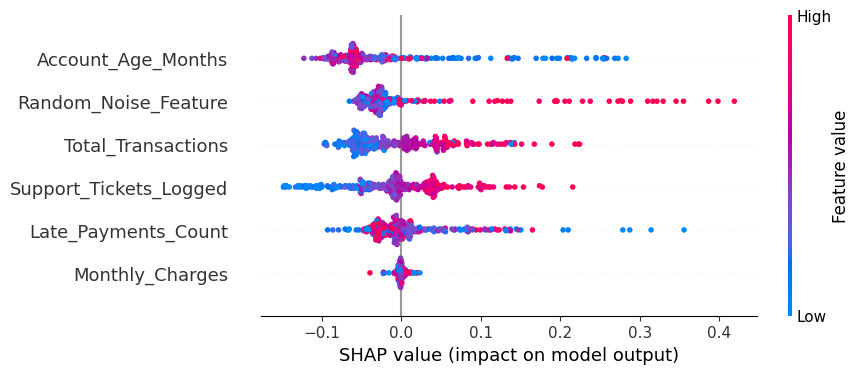

In [9]:
# 1. Global Feature Importance Bar Plot
plt.figure(figsize=(8, 4))
shap.plots.bar(shap_class1, max_display=6, show=True)

# 2. SHAP Beeswarm Plot (Direction + Magnitude Distribution)
plt.figure(figsize=(9, 5))
shap.plots.beeswarm(shap_class1, max_display=6, show=True)

---
## Part 3: Local Explainability (Auditing a Single Prediction with Waterfall Plot)

Here we take a single individual customer (`X_test.iloc[0]`) and inspect the step-by-step mathematical path that led to their prediction:
* **$E[f(X)]$ (Base value):** Average prediction across the training set.
* **Arrows / Bars:** Each feature's positive (red) or negative (blue) push.
* **$f(x)$:** Final output score for this specific customer.

--- Sample Observation 0 ---
Actual Label: 0
Predicted Probability for Class 1: 0.1378



,Account_Age_Months,Monthly_Charges,Total_Transactions,Late_Payments_Count,Support_Tickets_Logged,Random_Noise_Feature
654,0.592464,1.459218,0.51551,-0.498662,-0.622323,-0.75398


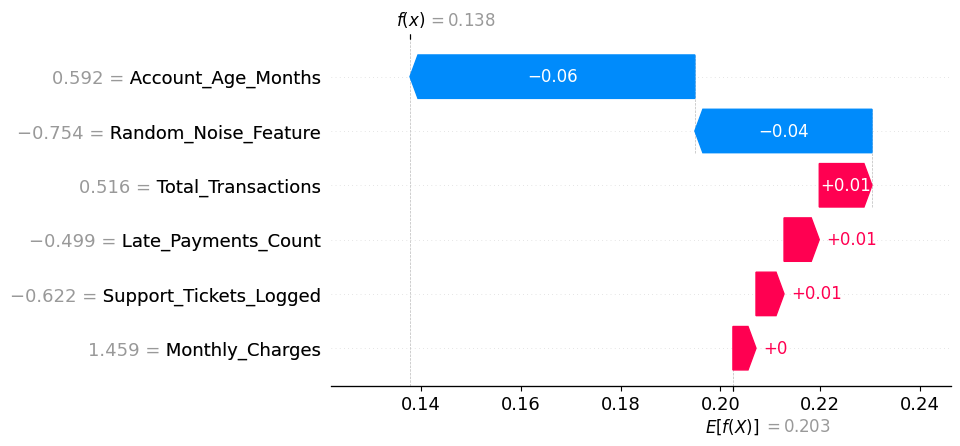

In [10]:
# Pick observation index 0 from the test set
sample_idx = 0
sample_record = X_test.iloc[[sample_idx]]

actual_label = y_test[sample_idx]
pred_prob = rf_model.predict_proba(sample_record)[0, 1]

print(f"--- Sample Observation {sample_idx} ---")
print(f"Actual Label: {actual_label}")
print(f"Predicted Probability for Class 1: {pred_prob:.4f}\n")
display(sample_record)

# Generate Waterfall Plot for this single prediction
plt.figure(figsize=(9, 5))
shap.plots.waterfall(shap_class1[sample_idx], show=True)

---
## Part 4: Key Takeaways for Technical Auditing & Interviews

1. **Beeswarm Diagnostics:**
   * A high value (red) of an informative feature clustered on the positive side of the x-axis means increasing that feature increases the likelihood of the positive outcome.
   * `Random_Noise_Feature` clusters symmetrically near 0 with minimal spread, confirming the model does not rely on it.
2. **Local Trust:**
   * The waterfall plot provides exact, compliance-friendly attribution for regulators or customers asking: *"Why was my loan denied or transaction flagged?"*